Slit 2/2/6
m_diff = 0.1639 ± 0.0067 cm
m_miss = 0.5568 ± 0.0134 cm
a = 3.874e-04 ± 1.594e-05 m
d/a = 3.397 ± 0.162

Slit 2/2/14
m_diff = 0.1057 ± 0.0091 cm
m_miss = 0.5976 ± 0.0052 cm
a = 6.009e-04 ± 5.192e-05 m
d/a = 5.655 ± 0.491


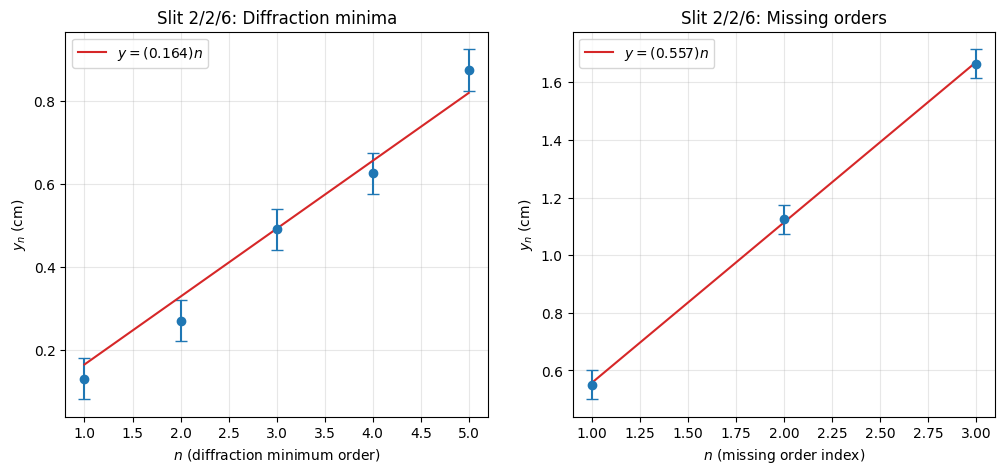

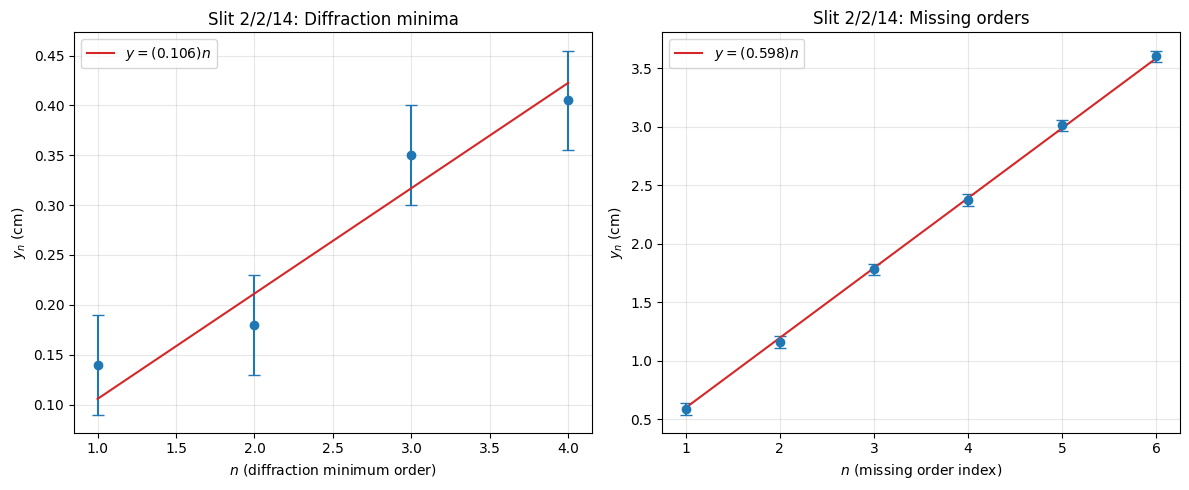

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

lam = 635e-9
L = 1.000
sigma_caliper = 0.05

def linear(n, m):
    return m * n

# Slit 2/2/6
n_6_diff = np.array([1, 2, 3, 4, 5])
y_6_diff = np.array([0.26, 0.54, 0.98, 1.25, 1.75]) / 2
sigma_6_diff = np.full_like(y_6_diff, 0.05)

n_6_miss = np.array([1, 2, 3])
y_6_miss = np.array([1.10, 2.25, 3.33]) / 2
sigma_6_miss = np.full_like(y_6_miss, 0.05)

popt_6d, pcov_6d = curve_fit(linear, n_6_diff, y_6_diff, sigma=sigma_6_diff, absolute_sigma=True)
popt_6m, pcov_6m = curve_fit(linear, n_6_miss, y_6_miss, sigma=sigma_6_miss, absolute_sigma=True)

m_6d = popt_6d[0]
sigma_m_6d = np.sqrt(np.diag(pcov_6d))[0]
m_6m = popt_6m[0]
sigma_m_6m = np.sqrt(np.diag(pcov_6m))[0]

a_6 = lam * L / (m_6d * 1e-2)
sigma_a_6 = a_6 * sigma_m_6d / m_6d
ratio_6 = m_6m / m_6d
sigma_ratio_6 = ratio_6 * np.sqrt((sigma_m_6m/m_6m)**2 + (sigma_m_6d/m_6d)**2)

print("Slit 2/2/6")
print(f"m_diff = {m_6d:.4f} ± {sigma_m_6d:.4f} cm")
print(f"m_miss = {m_6m:.4f} ± {sigma_m_6m:.4f} cm")
print(f"a = {a_6:.3e} ± {sigma_a_6:.3e} m")
print(f"d/a = {ratio_6:.3f} ± {sigma_ratio_6:.3f}")

# Slit 2/2/14
n_14_diff = np.array([1, 2, 3, 4])
y_14_diff = np.array([0.28, 0.36, 0.70, 0.81]) / 2
sigma_14_diff = np.full_like(y_14_diff, 0.05)

n_14_miss = np.array([1, 2, 3, 4, 5, 6])
y_14_miss = np.array([1.18, 2.32, 3.56, 4.74, 6.02, 7.20]) / 2
sigma_14_miss = np.full_like(y_14_miss, 0.05)

popt_14d, pcov_14d = curve_fit(linear, n_14_diff, y_14_diff, sigma=sigma_14_diff, absolute_sigma=True)
popt_14m, pcov_14m = curve_fit(linear, n_14_miss, y_14_miss, sigma=sigma_14_miss, absolute_sigma=True)

m_14d = popt_14d[0]
sigma_m_14d = np.sqrt(np.diag(pcov_14d))[0]
m_14m = popt_14m[0]
sigma_m_14m = np.sqrt(np.diag(pcov_14m))[0]

a_14 = lam * L / (m_14d * 1e-2)
sigma_a_14 = a_14 * sigma_m_14d / m_14d
ratio_14 = m_14m / m_14d
sigma_ratio_14 = ratio_14 * np.sqrt((sigma_m_14m/m_14m)**2 + (sigma_m_14d/m_14d)**2)

print("\nSlit 2/2/14")
print(f"m_diff = {m_14d:.4f} ± {sigma_m_14d:.4f} cm")
print(f"m_miss = {m_14m:.4f} ± {sigma_m_14m:.4f} cm")
print(f"a = {a_14:.3e} ± {sigma_a_14:.3e} m")
print(f"d/a = {ratio_14:.3f} ± {sigma_ratio_14:.3f}")

# Plots
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))

ax = axes1[0]
ax.errorbar(n_6_diff, y_6_diff, yerr=sigma_6_diff, fmt='o', capsize=4, color='tab:blue')
ax.plot(n_6_diff, linear(n_6_diff, *popt_6d), '-', color='tab:red',
        label=f'$y = ({m_6d:.3f})n$')
ax.set_xlabel('$n$ (diffraction minimum order)')
ax.set_ylabel('$y_n$ (cm)')
ax.set_title('Slit 2/2/6: Diffraction minima')
ax.legend()
ax.grid(alpha=0.3)

ax = axes1[1]
ax.errorbar(n_6_miss, y_6_miss, yerr=sigma_6_miss, fmt='o', capsize=4, color='tab:blue')
ax.plot(n_6_miss, linear(n_6_miss, *popt_6m), '-', color='tab:red',
        label=f'$y = ({m_6m:.3f})n$')
ax.set_xlabel('$n$ (missing order index)')
ax.set_ylabel('$y_n$ (cm)')
ax.set_title('Slit 2/2/6: Missing orders')
ax.legend()
ax.grid(alpha=0.3)

fig2, axes2 = plt.subplots(1, 2, figsize=(12,5))

ax = axes2[0]
ax.errorbar(n_14_diff, y_14_diff, yerr=sigma_14_diff, fmt='o', capsize=4, color='tab:blue')
ax.plot(n_14_diff, linear(n_14_diff, *popt_14d), '-', color='tab:red',
        label=f'$y = ({m_14d:.3f})n$')
ax.set_xlabel('$n$ (diffraction minimum order)')
ax.set_ylabel('$y_n$ (cm)')
ax.set_title('Slit 2/2/14: Diffraction minima')
ax.legend()
ax.grid(alpha=0.3)

ax = axes2[1]
ax.errorbar(n_14_miss, y_14_miss, yerr=sigma_14_miss, fmt='o', capsize=4, color='tab:blue')
ax.plot(n_14_miss, linear(n_14_miss, *popt_14m), '-', color='tab:red',
        label=f'$y = ({m_14m:.3f})n$')
ax.set_xlabel('$n$ (missing order index)')
ax.set_ylabel('$y_n$ (cm)')
ax.set_title('Slit 2/2/14: Missing orders')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('double_slit_fits.png', dpi=150)
plt.show()

m_fit = 4.1305e-04 ± 2.6922e-06 m
D     = 4.3602e-04 ± 2.8419e-06 m
R     = 2.1801e-04 ± 1.4210e-06 m


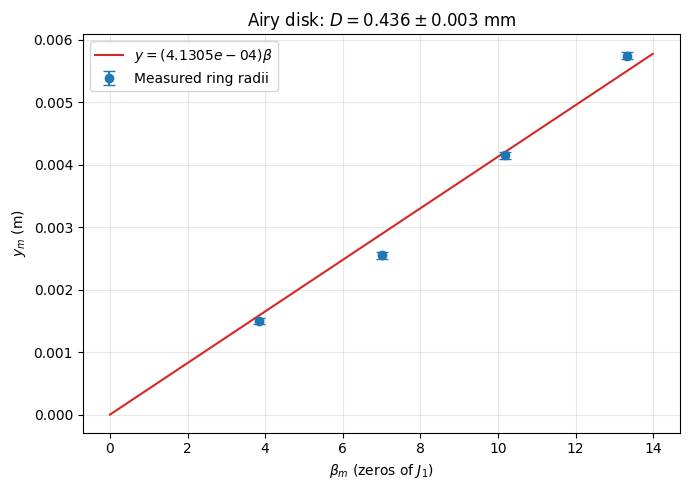

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn_zeros

lam = 635e-9
L = 0.891

beta = jn_zeros(1, 4)
y = np.array([0.30, 0.51, 0.83, 1.15]) / 2 / 100
sigma_y = np.array([0.01, 0.01, 0.01, 0.01]) / 2 / 100

def linear(beta, m):
    return m * beta

popt, pcov = curve_fit(linear, beta, y, sigma=sigma_y, absolute_sigma=True)
m_fit = popt[0]
sigma_m = np.sqrt(np.diag(pcov))[0]

D = lam * L / (np.pi * m_fit)
sigma_D = D * sigma_m / m_fit
R = D / 2
sigma_R = sigma_D / 2

print(f"m_fit = {m_fit:.4e} ± {sigma_m:.4e} m")
print(f"D     = {D:.4e} ± {sigma_D:.4e} m")
print(f"R     = {R:.4e} ± {sigma_R:.4e} m")

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(beta, y, yerr=sigma_y, fmt='o', capsize=4,
            color='tab:blue', label='Measured ring radii')

beta_line = np.linspace(0, beta.max() * 1.05, 100)
ax.plot(beta_line, linear(beta_line, *popt), '-', color='tab:red',
        label=f'$y = ({m_fit:.4e})\\beta$')

ax.set_xlabel('$\\beta_m$ (zeros of $J_1$)')
ax.set_ylabel('$y_m$ (m)')
ax.set_title(f'Airy disk: $D = {D*1e3:.3f} \\pm {sigma_D*1e3:.3f}$ mm')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bessel_zero_fit.png', dpi=150)
plt.show()